In [3]:
stock = pd.read_csv(
    "../data/processed/reliance_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)

In [4]:
stock.head()

,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Trading_Range,Price_Change,Volatility20,MA20,MA50,MA200,EMA20,Target
Date,,,,,,,,,,,,,,,,
2015-10-21,205.980759,218.296936,222.822876,217.839767,218.411224,14404450,-0.001777,-0.001779,4.983109,-0.114288,0.018993,203.392169,203.055238,206.833089,206.858732,1
2015-10-23,206.120972,218.445511,222.422867,215.131058,220.342758,12153422,0.000681,0.000680,7.291809,-1.897247,0.016707,204.623661,202.994663,206.910522,207.962235,0
2015-10-26,203.360184,215.519653,220.125595,215.165344,219.874161,10938775,-0.013394,-0.013485,4.960251,-4.354507,0.017261,205.680859,202.888829,206.976011,208.681989,0
2015-10-27,202.648407,214.765320,216.753998,214.273865,214.593887,11601798,-0.003500,-0.003506,2.480133,0.171432,0.016713,206.848918,202.873514,207.048814,209.261354,0
2015-10-28,202.087601,214.171005,215.988251,212.559494,214.159576,11958727,-0.002767,-0.002771,3.428757,0.011429,0.016686,208.022693,202.889972,207.164078,209.728940,1


In [5]:
features = [
    "Daily_Return",
    "Log_Return",
    "Trading_Range",
    "Price_Change",
    "Volatility20",
    "MA20",
    "MA50",
    "MA200",
    "EMA20"
]

X = stock[features]
y = stock["Target"]

In [9]:
print(type(X))
print(X.shape)

print(type(y))
print(y.shape)

NameError: name 'X' is not defined

In [6]:
print(X.shape)
print(y.shape)

(2268, 9)
(2268,)


In [7]:
tscv = TimeSeriesSplit(n_splits=5)

In [8]:
print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [7]:
stock.head()

,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Trading_Range,Price_Change,Volatility20,MA20,MA50,MA200,EMA20,Target
Date,,,,,,,,,,,,,,,,
2015-10-21,205.980759,218.296936,222.822876,217.839767,218.411224,14404450,-0.001777,-0.001779,4.983109,-0.114288,0.018993,203.392169,203.055238,206.833089,206.858732,1
2015-10-23,206.120972,218.445511,222.422867,215.131058,220.342758,12153422,0.000681,0.000680,7.291809,-1.897247,0.016707,204.623661,202.994663,206.910522,207.962235,0
2015-10-26,203.360184,215.519653,220.125595,215.165344,219.874161,10938775,-0.013394,-0.013485,4.960251,-4.354507,0.017261,205.680859,202.888829,206.976011,208.681989,0
2015-10-27,202.648407,214.765320,216.753998,214.273865,214.593887,11601798,-0.003500,-0.003506,2.480133,0.171432,0.016713,206.848918,202.873514,207.048814,209.261354,0
2015-10-28,202.087601,214.171005,215.988251,212.559494,214.159576,11958727,-0.002767,-0.002771,3.428757,0.011429,0.016686,208.022693,202.889972,207.164078,209.728940,1


In [8]:
stock.columns.tolist()

['Adj Close',
 'Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'Daily_Return',
 'Log_Return',
 'Trading_Range',
 'Price_Change',
 'Volatility20',
 'MA20',
 'MA50',
 'MA200',
 'EMA20',
 'Target']

In [9]:
scores = []

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    scores.append(accuracy)

    print("Fold Accuracy:", round(accuracy,4))

Fold Accuracy: 0.4577
Fold Accuracy: 0.5317
Fold Accuracy: 0.455
Fold Accuracy: 0.5503
Fold Accuracy: 0.4894


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [13]:
results = {}

for name, model in models.items():

    scores = []

    for train_index, test_index in tscv.split(X):

        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        scores.append(
            accuracy_score(y_test, predictions)
        )

    results[name] = np.mean(scores)

results

{'Logistic Regression': np.float64(0.4962962962962963),
 'Decision Tree': np.float64(0.49259259259259264),
 'Random Forest': np.float64(0.49682539682539684)}

In [14]:
comparison = pd.DataFrame(
    results.items(),
    columns=["Model", "Average Accuracy"]
)

comparison = comparison.sort_values(
    by="Average Accuracy",
    ascending=False
)

comparison

,Model,Average Accuracy
2,Random Forest,0.496825
0,Logistic Regression,0.496296
1,Decision Tree,0.492593


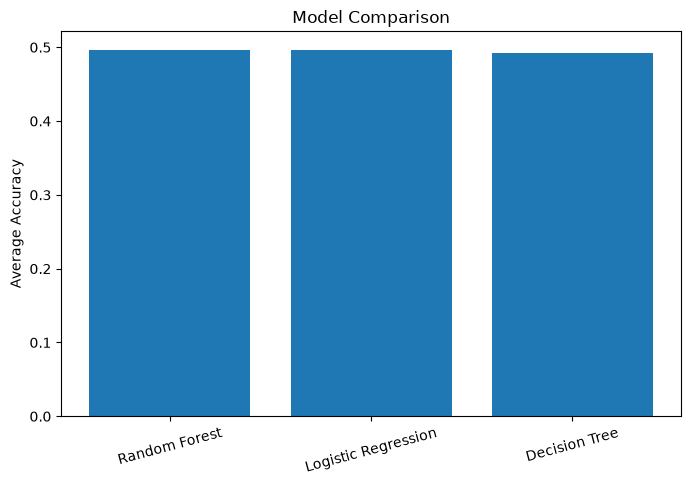

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Average Accuracy"]
)

plt.title("Model Comparison")
plt.ylabel("Average Accuracy")

plt.xticks(rotation=15)

plt.show()

In [10]:
print("Average Accuracy:", np.mean(scores))

Average Accuracy: 0.49682539682539684


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt